In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Dados-modelo/df_preliminar.csv', sep=';')

In [20]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'ACESSO_LOCAL', 'MULTIPLO_PESA', 'REGIAO',
       'PESA', 'MUNI_REFERENCIADO', 'OBSERVACOES', 'LAT_MUNI', 'LON_MUNI',
       'LAT_PESA', 'LON_PESA', 'DISTANCIA', 'TEMPO', 'IBGE', 'MUNI_NOME_x',
       'POP10', 'POP12', 'POP11A59', 'POP60', 'POP_GERAL', 'MACRO_CODIGO',
       'MACRO_NOME', 'DRS_CODIGO', 'DRS_NOME', 'CIR_CODIGO', 'CIR_NOME',
       'TOTAL_CASOS', 'TOTAL_10A', 'TOTAL_12A', 'TOTAL_11A59', 'TOTAL_60',
       'LEVE', 'MG', 'MG_ORIGINAL', 'LEVE_10', 'MG_10', 'LEVE_12', 'MG_12',
       'LEVE_11A59', 'MG_11A59', 'LEVE_60', 'MG_60', 'TOTAL_AMPOLAS',
       'CAT_TEMPO', 'PROP_POP_0A10', 'PROP_POP_60MAIS', 'LOG_POP', 'PROP_MG',
       'INCID_MEDIA_GERAL', 'INCID_0A10', 'INCID_60MAIS', 'PROP_CASOS_0A10',
       'PROP_CASOS_60MAIS', 'TAXA_MG_100MIL', 'CLASS_IG', 'SORO_IG', 'EVOL_IG',
       'PROP_CLASS_IGN', 'PROP_SORO_IGN', 'PROP_EVOL_IGN', 'BAIXO_N'],
      dtype='str')

## Caracterização geral

In [23]:
print(
    '========== DADOS GERAIS ==========\n'
    f'Total de municípios: {len(df)}\n'
    f'Total de casos: {df["TOTAL_CASOS"].sum():,.0f}\n'
    f'Total de casos leves: {df["LEVE"].sum():,.0f}\n'
    f'Total de casos MG: {df["MG"].sum():,.0f}\n'
    f'Proporção de MG: {100*df["MG"].sum()/df["TOTAL_CASOS"].sum():.2f}%\n'
    '\n'
    '========== FAIXA ETÁRIA ==========\n'
    f'Total <10 anos: {(df["LEVE_10"] + df["MG_10"]).sum():,.0f}\n'
    f'Casos MG <10 anos: {df["MG_10"].sum():,.0f}\n'
    f'Proporção MG <10 anos: {100*df["MG_10"].sum()/(df["LEVE_10"] + df["MG_10"]).sum():.2f}%\n'
    '\n'
    f'Total ≥60 anos: {(df["LEVE_60"] + df["MG_60"]).sum():,.0f}\n'
    f'Casos MG ≥60 anos: {df["MG_60"].sum():,.0f}\n'
    f'Proporção MG ≥60 anos: {100*df["MG_60"].sum()/(df["LEVE_60"] + df["MG_60"]).sum():.2f}%'
)

========== DADOS GERAIS ==========
Total de municípios: 645
Total de casos: 117,356
Total de casos leves: 109,704
Total de casos MG: 7,652
Proporção de MG: 6.52%

========== FAIXA ETÁRIA ==========
Total <10 anos: 10,673
Casos MG <10 anos: 2,689
Proporção MG <10 anos: 25.19%

Total ≥60 anos: 21,646
Casos MG ≥60 anos: 937
Proporção MG ≥60 anos: 4.33%


In [29]:
print(
    '\n========== ACESSO AO PESA ==========\n'
    f'Municípios: {len(df)}\n'
    f'Com PESA local: {(df["TEMPO"]==0).sum()}\n'
    f'Sem PESA local: {(df["TEMPO"]>0).sum()}\n'
    f'% com PESA local: {100*(df["TEMPO"]==0).mean():.1f}%'
)


========== ACESSO AO PESA ==========
Municípios: 645
Com PESA local: 202
Sem PESA local: 443
% com PESA local: 31.3%


In [30]:
print(
    '\n========== MUNICÍPIOS COM MG ==========\n'
    f'Municípios com pelo menos 1 MG: {(df["MG"]>0).sum()}\n'
    f'Municípios sem MG: {(df["MG"]==0).sum()}\n'
    f'% sem MG: {100*(df["MG"]==0).mean():.1f}%'
)


========== MUNICÍPIOS COM MG ==========
Municípios com pelo menos 1 MG: 543
Municípios sem MG: 102
% sem MG: 15.8%


In [ ]:
# Resumo estatístico das variáveis contínuas

variaveis = [
    'TEMPO',
    'DISTANCIA',
    'INCID_MEDIA_GERAL',
    'PROP_MG',
    'PROP_CASOS_0A10',
    'PROP_CASOS_60MAIS'
]

resumo = (
    df[variaveis]
    .describe(percentiles=[0.05,0.10,0.25,0.50,0.75,0.90,0.95])
    .T
)

resumo = resumo.rename(columns={
    'count':'N',
    'mean':'Média',
    'std':'DP',
    'min':'Mínimo',
    '5%':'P5',
    '10%':'P10',
    '25%':'Q1',
    '50%':'Mediana',
    '75%':'Q3',
    '90%':'P90',
    '95%':'P95',
    'max':'Máximo'
})

display(resumo.round(2))

,N,Média,DP,Mínimo,P5,P10,Q1,Mediana,Q3,P90,P95,Máximo
TEMPO,645.0,18.91,16.19,0.0,0.00,0.0,0.00,19.50,29.00,40.96,47.32,70.80
DISTANCIA,645.0,18.81,16.99,0.0,0.00,0.0,0.00,18.10,30.00,41.16,50.20,84.40
INCID_MEDIA_GERAL,645.0,167.22,203.71,0.0,1.17,4.0,20.86,87.82,236.00,473.83,635.46,1084.77
PROP_MG,645.0,0.10,0.14,0.0,0.00,0.0,0.03,0.06,0.12,0.24,0.33,1.00
PROP_CASOS_0A10,645.0,0.10,0.11,0.0,0.00,0.0,0.05,0.08,0.12,0.18,0.26,1.00
PROP_CASOS_60MAIS,645.0,0.16,0.11,0.0,0.00,0.0,0.10,0.17,0.22,0.27,0.33,1.00


In [ ]:
# Assimetria
print(df[variaveis].skew().round(2))
'''Regra prática:

|Skew| < 0,5 → aproximadamente simétrica
0,5–1 → moderadamente assimétrica

1 → bastante assimétrica

Isso já indica se faz sentido usar média ou mediana.'''

TEMPO                0.43
DISTANCIA            0.68
INCID_MEDIA_GERAL    1.77
PROP_MG              3.60
PROP_CASOS_0A10      4.16
PROP_CASOS_60MAIS    1.67
dtype: float64


In [4]:
# Correlacao 1
cols = [
    'TEMPO',
    'DISTANCIA',
    'INCID_MEDIA_GERAL',
    'PROP_MG',
    'PROP_POP_0A10',
    'PROP_POP_60MAIS'
]

df[cols].corr().round(2)

,TEMPO,DISTANCIA,INCID_MEDIA_GERAL,PROP_MG,PROP_POP_0A10,PROP_POP_60MAIS
TEMPO,1.00,0.98,0.08,-0.06,-0.04,0.15
DISTANCIA,0.98,1.00,0.09,-0.08,-0.05,0.16
INCID_MEDIA_GERAL,0.08,0.09,1.00,-0.23,-0.32,0.34
PROP_MG,-0.06,-0.08,-0.23,1.00,0.18,-0.14
PROP_POP_0A10,-0.04,-0.05,-0.32,0.18,1.00,-0.69
PROP_POP_60MAIS,0.15,0.16,0.34,-0.14,-0.69,1.00


In [5]:
# Listar extremos

display(
df.nlargest(20, 'PROP_MG')['MUNI_REFERENCIADO'],

df.nlargest(20, 'TEMPO')['MUNI_REFERENCIADO'],

df.nlargest(20, 'INCID_MEDIA_GERAL')['MUNI_REFERENCIADO']
)

164               NOVA CAMPINA
165                    RIBEIRA
398    SANTO ANTONIO DO PINHAL
535                JACUPIRANGA
540                SETE BARRAS
592                      APIAI
549                   BERTIOGA
556                     SANTOS
294                    SERRANA
112                 ITAPORANGA
121                     TAGUAI
584                   ANGATUBA
66                     GUARACI
162     BOM SUCESSO DE ITARARE
292                  SAO SIMAO
299        RIO GRANDE DA SERRA
306               DIVINOLANDIA
543                     CAJURU
586               ITAPETININGA
555               PRAIA GRANDE
Name: MUNI_REFERENCIADO, dtype: str

141                  PIRACAIA
392       NATIVIDADE DA SERRA
117                 PORANGABA
429                 UBIRAJARA
328                    IRAPUA
162    BOM SUCESSO DE ITARARE
165                   RIBEIRA
123            TORRE DE PEDRA
344            PAULO DE FARIA
67                  JABORANDI
63                    TIMBURI
326            GASTAO VIDIGAL
101                       URU
421                  GUARANTA
330                  MACAUBAL
103                   ANHEMBI
31                    DOURADO
166                  RIVERSUL
415     CAMPOS NOVOS PAULISTA
417                    FERNAO
Name: MUNI_REFERENCIADO, dtype: str

174                  INDIAPORA
15            MURUTINGA DO SUL
246       SANTA MARIA DA SERRA
447                   GUARACAI
270              MONTE CASTELO
632              MIRASSOLANDIA
641                 ONDA VERDE
315           ALVARES FLORENCE
179               MIRA ESTRELA
582                   OUROESTE
340                  PALESTINA
2                      BARBOSA
520    MIRANTE DO PARANAPANEMA
450               MIRANDOPOLIS
273                  PAULICEIA
343                     PARISI
183               PEDRANOPOLIS
271          NOVA GUATAPORANGA
17          NOVA INDEPENDENCIA
633                POTIRENDABA
Name: MUNI_REFERENCIADO, dtype: str

In [6]:
# Correlação 2
cols = [
    'TEMPO',
    'DISTANCIA',
    'INCID_MEDIA_GERAL',
    'PROP_MG',
    'PROP_CASOS_0A10',
    'PROP_CASOS_60MAIS'
]

df[cols].corr().round(2)

,TEMPO,DISTANCIA,INCID_MEDIA_GERAL,PROP_MG,PROP_CASOS_0A10,PROP_CASOS_60MAIS
TEMPO,1.00,0.98,0.08,-0.06,0.04,0.04
DISTANCIA,0.98,1.00,0.09,-0.08,0.05,0.05
INCID_MEDIA_GERAL,0.08,0.09,1.00,-0.23,-0.09,0.32
PROP_MG,-0.06,-0.08,-0.23,1.00,0.20,-0.05
PROP_CASOS_0A10,0.04,0.05,-0.09,0.20,1.00,-0.18
PROP_CASOS_60MAIS,0.04,0.05,0.32,-0.05,-0.18,1.00


In [7]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'ACESSO_LOCAL', 'MULTIPLO_PESA', 'REGIAO',
       'PESA', 'MUNI_REFERENCIADO', 'OBSERVACOES', 'LAT_MUNI', 'LON_MUNI',
       'LAT_PESA', 'LON_PESA', 'DISTANCIA', 'TEMPO', 'IBGE', 'MUNI_NOME_x',
       'POP10', 'POP12', 'POP11A59', 'POP60', 'POP_GERAL', 'MACRO_CODIGO',
       'MACRO_NOME', 'DRS_CODIGO', 'DRS_NOME', 'CIR_CODIGO', 'CIR_NOME',
       'TOTAL_CASOS', 'TOTAL_10A', 'TOTAL_12A', 'TOTAL_11A59', 'TOTAL_60',
       'LEVE', 'MG', 'MG_ORIGINAL', 'LEVE_10', 'MG_10', 'LEVE_12', 'MG_12',
       'LEVE_11A59', 'MG_11A59', 'LEVE_60', 'MG_60', 'TOTAL_AMPOLAS',
       'CAT_TEMPO', 'PROP_POP_0A10', 'PROP_POP_60MAIS', 'LOG_POP', 'PROP_MG',
       'INCID_MEDIA_GERAL', 'INCID_0A10', 'INCID_60MAIS', 'PROP_CASOS_0A10',
       'PROP_CASOS_60MAIS', 'TAXA_MG_100MIL', 'CLASS_IG', 'SORO_IG', 'EVOL_IG',
       'PROP_CLASS_IGN', 'PROP_SORO_IGN', 'PROP_EVOL_IGN', 'BAIXO_N'],
      dtype='str')

In [8]:
df['MG'].sum()

np.int64(7652)

In [9]:
df['MG_ORIGINAL'].sum()

np.int64(5398)

In [10]:
dd = df[df['PROP_MG'] > 0]

In [11]:
dd['PROP_MG'].describe()

count    543.000000
mean       0.121142
std        0.142929
min        0.010000
25%        0.050000
50%        0.080000
75%        0.140000
max        1.000000
Name: PROP_MG, dtype: float64

<Axes: xlabel='CAT_TEMPO', ylabel='PROP_MG'>

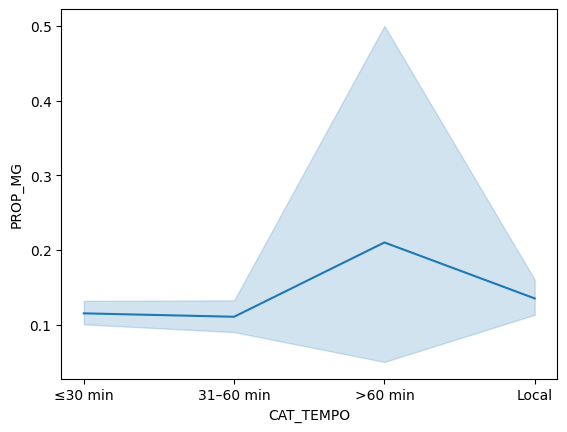

In [12]:
plt.clf()
sns.lineplot(x = 'CAT_TEMPO', y='PROP_MG', data=dd)

<Figure size 640x480 with 0 Axes>

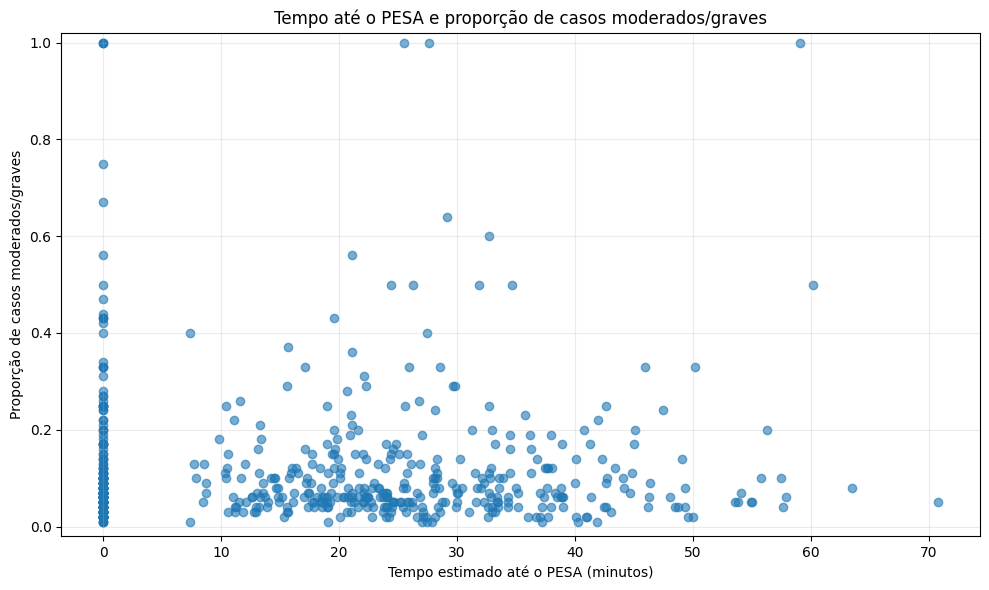

In [13]:
plt.clf()
plt.figure(figsize=(10, 6))

plt.scatter(
    dd["TEMPO"],
    dd["PROP_MG"],
    alpha=0.6
)

plt.xlabel("Tempo estimado até o PESA (minutos)")
plt.ylabel("Proporção de casos moderados/graves")
plt.title("Tempo até o PESA e proporção de casos moderados/graves")

plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()